# Linear Regression 2.1 - FIFA World Cup 2026 Goal Difference Prediction

## Step 1: Load and Inspect the Pre-Match Dataset

In [1]:
import pandas as pd

In [2]:
features_df = pd.read_csv('/Users/apuu/Desktop/Assessment3_LinearRegression_2_1/data/match_prediction_features_X.csv')

In [3]:
features_df.head()

,match_id,date,kickoff_time_utc,stage_id,is_knockout,home_team_id,home_team_name,home_fifa_code,home_confederation,away_team_id,...,home_prev_avg_corners,away_prev_avg_corners,home_prev_avg_fouls,away_prev_avg_fouls,home_prev_avg_offsides,away_prev_avg_offsides,home_prev_avg_xg_scored,home_prev_avg_xg_conceded,away_prev_avg_xg_scored,away_prev_avg_xg_conceded
0,1,2026-06-11,19:00,1,0,1,Mexico,MEX,CONCACAF,2,...,5.0,5.0,12.0,12.0,2.0,2.0,1.3,1.3,1.3,1.3
1,2,2026-06-11,23:00,1,0,3,South Korea,KOR,AFC,4,...,5.0,5.0,12.0,12.0,2.0,2.0,1.3,1.3,1.3,1.3
2,3,2026-06-12,19:00,1,0,5,Canada,CAN,CONCACAF,6,...,5.0,5.0,12.0,12.0,2.0,2.0,1.3,1.3,1.3,1.3
3,4,2026-06-12,23:00,1,0,13,USA,USA,CONCACAF,14,...,5.0,5.0,12.0,12.0,2.0,2.0,1.3,1.3,1.3,1.3
4,5,2026-06-13,15:00,1,0,7,Qatar,QAT,AFC,8,...,5.0,5.0,12.0,12.0,2.0,2.0,1.3,1.3,1.3,1.3


In [4]:
features_df.shape

(104, 60)

In [5]:
features_df.columns.tolist()

['match_id',
 'date',
 'kickoff_time_utc',
 'stage_id',
 'is_knockout',
 'home_team_id',
 'home_team_name',
 'home_fifa_code',
 'home_confederation',
 'away_team_id',
 'away_team_name',
 'away_fifa_code',
 'away_confederation',
 'venue_id',
 'stadium_name',
 'venue_city',
 'venue_country',
 'venue_capacity',
 'venue_elevation_meters',
 'referee_id',
 'referee_name',
 'referee_avg_cards',
 'home_fifa_rank',
 'away_fifa_rank',
 'home_elo',
 'away_elo',
 'home_is_host',
 'away_is_host',
 'home_squad_avg_age',
 'away_squad_avg_age',
 'home_squad_total_caps',
 'away_squad_total_caps',
 'home_squad_total_value_eur',
 'away_squad_total_value_eur',
 'home_squad_avg_value_eur',
 'away_squad_avg_value_eur',
 'home_rest_days',
 'away_rest_days',
 'home_prev_avg_goals_scored',
 'home_prev_avg_goals_conceded',
 'away_prev_avg_goals_scored',
 'away_prev_avg_goals_conceded',
 'home_prev_avg_possession',
 'away_prev_avg_possession',
 'home_prev_avg_shots',
 'away_prev_avg_shots',
 'home_prev_avg_shots

In [152]:
targets_df = pd.read_csv('/Users/apuu/Desktop/Assessment3_LinearRegression_2_1/data/match_prediction_targets_y.csv')

In [153]:
targets_df.head()

,match_id,home_score,away_score,result_type,home_xg,away_xg,match_result
0,1,2,0,Regular,1.84,0.52,H
1,2,2,1,Regular,1.45,1.12,H
2,3,1,1,Regular,1.35,0.98,D
3,4,4,1,Regular,2.76,0.88,H
4,5,1,1,Regular,0.78,1.54,D


In [8]:
targets_df["goal_difference"] = targets_df["home_score"] - targets_df["away_score"]

In [9]:
targets_df[["match_id", "home_score", "away_score", "goal_difference"]].head()

,match_id,home_score,away_score,goal_difference
0,1,2,0,2
1,2,2,1,1
2,3,1,1,0
3,4,4,1,3
4,5,1,1,0


In [10]:
targets_df.shape

(104, 8)

In [11]:
targets_df["match_id"].nunique()

104

In [12]:
features_df["match_id"].nunique()

104

In [13]:
features_df["match_id"].nunique()

104

In [14]:
set(features_df["match_id"]) == set(targets_df["match_id"])

True

In [15]:
features_df.shape

(104, 60)

In [16]:
model_df = pd.merge(
    features_df,
    targets_df[["match_id", "goal_difference"]],
    on="match_id",
    how="inner"
)

In [17]:
model_df.shape

(104, 61)

In [18]:
model_df["fifa_rank_advantage"] = (
    model_df["away_fifa_rank"] - model_df["home_fifa_rank"]
)

In [19]:
model_df[
    [
        "home_team_name",
        "away_team_name",
        "home_fifa_rank",
        "away_fifa_rank",
        "fifa_rank_advantage"
    ]
].head()

,home_team_name,away_team_name,home_fifa_rank,away_fifa_rank,fifa_rank_advantage
0,Mexico,South Africa,14,60,46
1,South Korea,Czechia,22,40,18
2,Canada,Bosnia and Herzegovina,33,64,31
3,USA,Paraguay,17,54,37
4,Qatar,Switzerland,56,19,-37


### Data Source

The analysis used the FIFA World Cup 2026 match-prediction feature and target datasets. The feature dataset contains pre-match explanatory variables, while the target dataset contains observed match outcomes.

The tournament contained 104 matches. Match results were cross-checked against the official FIFA World Cup 2026 fixtures and results page to support the accuracy of the response data used in this analysis.

In [20]:
model_df["elo_difference"] = (
    model_df["home_elo"] - model_df["away_elo"]
)

In [21]:
model_df[
    [
        "home_team_name",
        "away_team_name",
        "home_elo",
        "away_elo",
        "elo_difference"
    ]
].head()

,home_team_name,away_team_name,home_elo,away_elo,elo_difference
0,Mexico,South Africa,1810.0,1620.0,190.0
1,South Korea,Czechia,1800.0,1740.0,60.0
2,Canada,Bosnia and Herzegovina,1795.0,1645.0,150.0
3,USA,Paraguay,1850.0,1725.0,125.0
4,Qatar,Switzerland,1600.0,1860.0,-260.0


In [22]:
model_df["squad_value_difference"] = (
    model_df["home_squad_total_value_eur"]
    - model_df["away_squad_total_value_eur"]
)

In [23]:
model_df[
    [
        "home_team_name",
        "away_team_name",
        "home_squad_total_value_eur",
        "away_squad_total_value_eur",
        "squad_value_difference"
    ]
].head()

,home_team_name,away_team_name,home_squad_total_value_eur,away_squad_total_value_eur,squad_value_difference
0,Mexico,South Africa,411906509.0,47700000.0,364206509.0
1,South Korea,Czechia,139050000.0,187141830.0,-48091830.0
2,Canada,Bosnia and Herzegovina,204233523.0,146400000.0,57833523.0
3,USA,Paraguay,386573723.0,135683726.0,250889997.0
4,Qatar,Switzerland,121299976.0,357184518.0,-235884542.0


In [24]:
model_df["squad_experience_difference"] = (
    model_df["home_squad_total_caps"]
    - model_df["away_squad_total_caps"]
)

In [25]:
model_df[
    [
        "home_team_name",
        "away_team_name",
        "home_squad_total_caps",
        "away_squad_total_caps",
        "squad_experience_difference"
    ]
].head()

,home_team_name,away_team_name,home_squad_total_caps,away_squad_total_caps,squad_experience_difference
0,Mexico,South Africa,1237,538,699
1,South Korea,Czechia,974,738,236
2,Canada,Bosnia and Herzegovina,973,613,360
3,USA,Paraguay,977,705,272
4,Qatar,Switzerland,1586,1148,438


In [26]:
model_df["rest_days_difference"] = (
    model_df["home_rest_days"]
    - model_df["away_rest_days"]
)

In [27]:
model_df[
    [
        "home_team_name",
        "away_team_name",
        "home_rest_days",
        "away_rest_days",
        "rest_days_difference"
    ]
].head()

,home_team_name,away_team_name,home_rest_days,away_rest_days,rest_days_difference
0,Mexico,South Africa,10.0,10.0,0.0
1,South Korea,Czechia,10.0,10.0,0.0
2,Canada,Bosnia and Herzegovina,10.0,10.0,0.0
3,USA,Paraguay,10.0,10.0,0.0
4,Qatar,Switzerland,10.0,10.0,0.0


In [28]:
model_df["rest_days_difference"].value_counts().sort_index()

rest_days_difference
-1.0     6
 0.0    82
 1.0    13
 2.0     2
 3.0     1
Name: count, dtype: int64

In [29]:
model_df["previous_goals_scored_difference"] = (
    model_df["home_prev_avg_goals_scored"]
    - model_df["away_prev_avg_goals_scored"]
)

In [30]:
model_df[
    [
        "home_team_name",
        "away_team_name",
        "home_prev_avg_goals_scored",
        "away_prev_avg_goals_scored",
        "previous_goals_scored_difference"
    ]
].head()

,home_team_name,away_team_name,home_prev_avg_goals_scored,away_prev_avg_goals_scored,previous_goals_scored_difference
0,Mexico,South Africa,0.0,0.0,0.0
1,South Korea,Czechia,0.0,0.0,0.0
2,Canada,Bosnia and Herzegovina,0.0,0.0,0.0
3,USA,Paraguay,0.0,0.0,0.0
4,Qatar,Switzerland,0.0,0.0,0.0


In [31]:
model_df["previous_goals_scored_difference"].value_counts().sort_index()

previous_goals_scored_difference
-4.500000     1
-3.000000     3
-2.500000     1
-2.000000     3
-1.500000     2
-1.333333     1
-1.000000     8
-0.857143     1
-0.800000     1
-0.666667     1
-0.666667     1
-0.500000     5
-0.333333     1
-0.250000     1
 0.000000    36
 0.200000     1
 0.250000     1
 0.285714     1
 0.333333     1
 0.500000     4
 0.666667     1
 0.666667     2
 0.800000     1
 0.833333     1
 1.000000     2
 1.000000    12
 1.250000     1
 1.333333     2
 2.000000     4
 2.666667     1
 3.000000     2
 6.000000     1
Name: count, dtype: int64

In [32]:
model_df["defensive_advantage"] = (
    model_df["away_prev_avg_goals_conceded"]
    - model_df["home_prev_avg_goals_conceded"]
)

In [33]:
model_df[
    [
        "home_team_name",
        "away_team_name",
        "home_prev_avg_goals_conceded",
        "away_prev_avg_goals_conceded",
        "defensive_advantage"
    ]
].head()

,home_team_name,away_team_name,home_prev_avg_goals_conceded,away_prev_avg_goals_conceded,defensive_advantage
0,Mexico,South Africa,0.0,0.0,0.0
1,South Korea,Czechia,0.0,0.0,0.0
2,Canada,Bosnia and Herzegovina,0.0,0.0,0.0
3,USA,Paraguay,0.0,0.0,0.0
4,Qatar,Switzerland,0.0,0.0,0.0


In [34]:
model_df["defensive_advantage"].value_counts().sort_index()

defensive_advantage
-3.000000     2
-2.500000     2
-2.000000     3
-1.500000     2
-1.000000     8
-0.800000     1
-0.750000     1
-0.500000     5
-0.400000     1
-0.333333     1
-0.166667     1
 0.000000    38
 0.250000     2
 0.333333     2
 0.333333     2
 0.400000     1
 0.500000     2
 0.571429     1
 0.666667     1
 0.666667     2
 0.750000     1
 0.857143     1
 1.000000     7
 1.333333     3
 1.500000     3
 1.666667     2
 2.000000     5
 3.000000     3
 6.000000     1
Name: count, dtype: int64

In [35]:
model_df["host_advantage"] = (
    model_df["home_is_host"]
    - model_df["away_is_host"]
)

In [36]:
model_df[
    [
        "home_team_name",
        "away_team_name",
        "home_is_host",
        "away_is_host",
        "host_advantage"
    ]
].head()

,home_team_name,away_team_name,home_is_host,away_is_host,host_advantage
0,Mexico,South Africa,1,0,1
1,South Korea,Czechia,0,0,0
2,Canada,Bosnia and Herzegovina,1,0,1
3,USA,Paraguay,1,0,1
4,Qatar,Switzerland,0,0,0


In [37]:
lr21_df = model_df[
    [
        "match_id",
        "fifa_rank_advantage",
        "elo_difference",
        "squad_value_difference",
        "squad_experience_difference",
        "rest_days_difference",
        "previous_goals_scored_difference",
        "defensive_advantage",
        "host_advantage",
        "goal_difference"
    ]
].copy()

In [38]:
lr21_df.shape

(104, 10)

In [39]:
lr21_df.head()

,match_id,fifa_rank_advantage,elo_difference,squad_value_difference,squad_experience_difference,rest_days_difference,previous_goals_scored_difference,defensive_advantage,host_advantage,goal_difference
0,1,46,190.0,364206509.0,699,0.0,0.0,0.0,1,2
1,2,18,60.0,-48091830.0,236,0.0,0.0,0.0,0,1
2,3,31,150.0,57833523.0,360,0.0,0.0,0.0,1,0
3,4,37,125.0,250889997.0,272,0.0,0.0,0.0,1,3
4,5,-37,-260.0,-235884542.0,438,0.0,0.0,0.0,0,0


In [40]:
lr21_df.isnull().sum()

match_id                            0
fifa_rank_advantage                 0
elo_difference                      0
squad_value_difference              0
squad_experience_difference         0
rest_days_difference                0
previous_goals_scored_difference    0
defensive_advantage                 0
host_advantage                      0
goal_difference                     0
dtype: int64

In [41]:
lr21_df.duplicated().sum()

np.int64(0)

In [42]:
lr21_df.dtypes

match_id                              int64
fifa_rank_advantage                   int64
elo_difference                      float64
squad_value_difference              float64
squad_experience_difference           int64
rest_days_difference                float64
previous_goals_scored_difference    float64
defensive_advantage                 float64
host_advantage                        int64
goal_difference                       int64
dtype: object

In [43]:
lr21_df["host_advantage"].value_counts().sort_index()

host_advantage
-1     3
 0    91
 1    10
Name: count, dtype: int64

In [44]:
lr21_df.to_csv(
    "../data/linear_regression_2_1_dataset.csv",
    index=False
)

In [45]:
saved_lr21_df = pd.read_csv("../data/linear_regression_2_1_dataset.csv")

saved_lr21_df.shape

(104, 10)

In [46]:
lr21_df.drop(columns="match_id").describe()

,fifa_rank_advantage,elo_difference,squad_value_difference,squad_experience_difference,rest_days_difference,previous_goals_scored_difference,defensive_advantage,host_advantage,goal_difference
count,104.000000,104.000000,1.040000e+02,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,7.000000,57.019231,1.809516e+08,52.432692,0.134615,0.066140,0.175916,0.067308,0.480769
std,33.654152,236.672441,6.817432e+08,307.596532,0.575515,1.333665,1.270878,0.348768,2.024034
min,-76.000000,-540.000000,-1.813827e+09,-973.000000,-1.000000,-4.500000,-3.000000,-1.000000,-4.000000
25%,-15.000000,-112.500000,-1.674659e+08,-104.250000,0.000000,-0.500000,-0.208333,0.000000,-1.000000
50%,7.000000,60.000000,1.530351e+08,74.500000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32.000000,226.250000,4.899664e+08,266.500000,0.000000,0.808333,0.687500,0.000000,2.000000
max,77.000000,510.000000,2.038847e+09,703.000000,3.000000,6.000000,6.000000,1.000000,6.000000


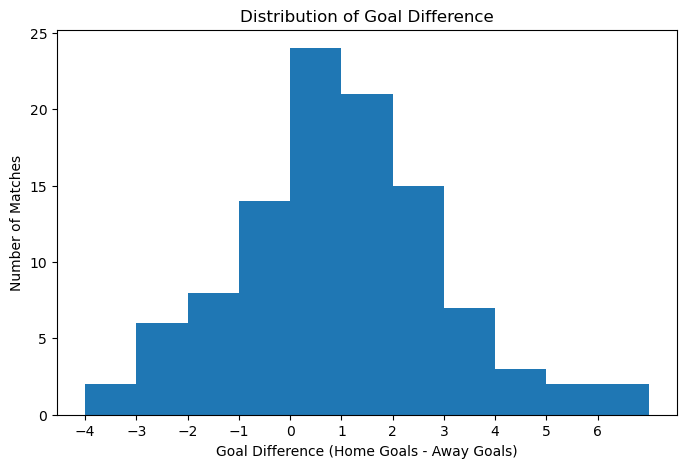

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    lr21_df["goal_difference"],
    bins=range(-4, 8)
)

plt.xlabel("Goal Difference (Home Goals - Away Goals)")
plt.ylabel("Number of Matches")
plt.title("Distribution of Goal Difference")
plt.xticks(range(-4, 7))

plt.show()

In [48]:
correlation_matrix = lr21_df.drop(columns="match_id").corr()

correlation_matrix.round(2)

,fifa_rank_advantage,elo_difference,squad_value_difference,squad_experience_difference,rest_days_difference,previous_goals_scored_difference,defensive_advantage,host_advantage,goal_difference
fifa_rank_advantage,1.00,0.94,0.67,0.38,-0.12,0.30,0.33,0.14,0.61
elo_difference,0.94,1.00,0.79,0.26,-0.11,0.36,0.33,0.02,0.65
squad_value_difference,0.67,0.79,1.00,0.01,-0.07,0.30,0.33,-0.03,0.57
squad_experience_difference,0.38,0.26,0.01,1.00,-0.10,0.18,0.07,0.20,0.09
rest_days_difference,-0.12,-0.11,-0.07,-0.10,1.00,-0.02,0.02,0.10,-0.01
previous_goals_scored_difference,0.30,0.36,0.30,0.18,-0.02,1.00,0.01,0.18,0.14
defensive_advantage,0.33,0.33,0.33,0.07,0.02,0.01,1.00,0.08,0.31
host_advantage,0.14,0.02,-0.03,0.20,0.10,0.18,0.08,1.00,0.16
goal_difference,0.61,0.65,0.57,0.09,-0.01,0.14,0.31,0.16,1.00


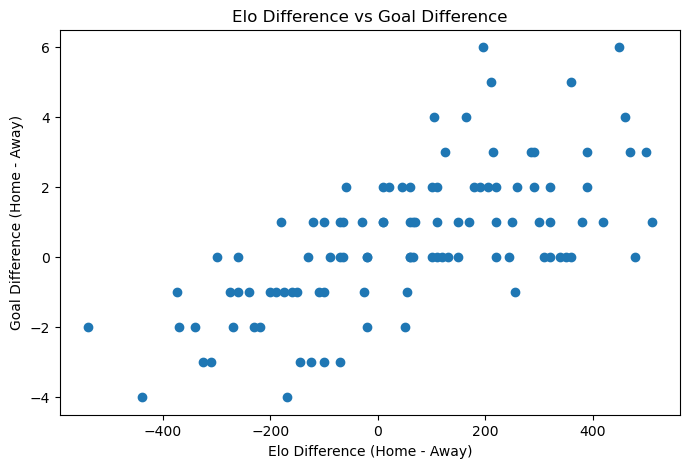

In [49]:
plt.figure(figsize=(8, 5))

plt.scatter(
    lr21_df["elo_difference"],
    lr21_df["goal_difference"]
)

plt.xlabel("Elo Difference (Home - Away)")
plt.ylabel("Goal Difference (Home - Away)")
plt.title("Elo Difference vs Goal Difference")

plt.show()

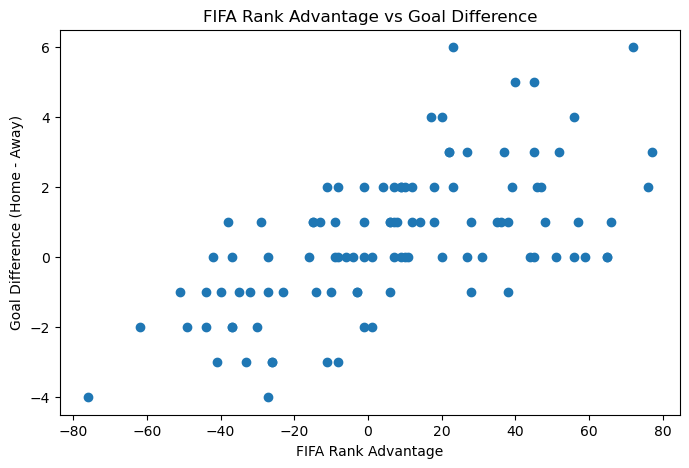

In [50]:
plt.figure(figsize=(8, 5))

plt.scatter(
    lr21_df["fifa_rank_advantage"],
    lr21_df["goal_difference"]
)

plt.xlabel("FIFA Rank Advantage")
plt.ylabel("Goal Difference (Home - Away)")
plt.title("FIFA Rank Advantage vs Goal Difference")

plt.show()

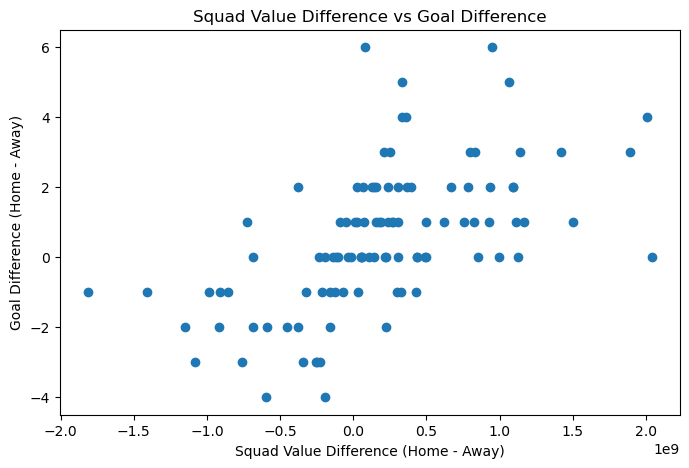

In [51]:
plt.figure(figsize=(8, 5))

plt.scatter(
    lr21_df["squad_value_difference"],
    lr21_df["goal_difference"]
)

plt.xlabel("Squad Value Difference (Home - Away)")
plt.ylabel("Goal Difference (Home - Away)")
plt.title("Squad Value Difference vs Goal Difference")

plt.show()

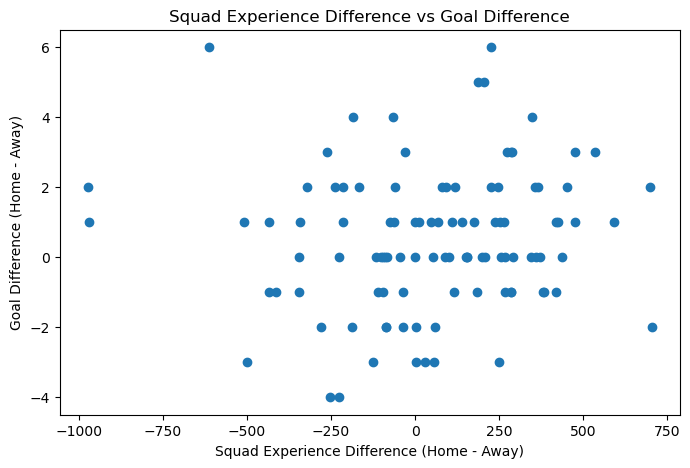

In [52]:
plt.figure(figsize=(8, 5))

plt.scatter(
    lr21_df["squad_experience_difference"],
    lr21_df["goal_difference"]
)

plt.xlabel("Squad Experience Difference (Home - Away)")
plt.ylabel("Goal Difference (Home - Away)")
plt.title("Squad Experience Difference vs Goal Difference")

plt.show()

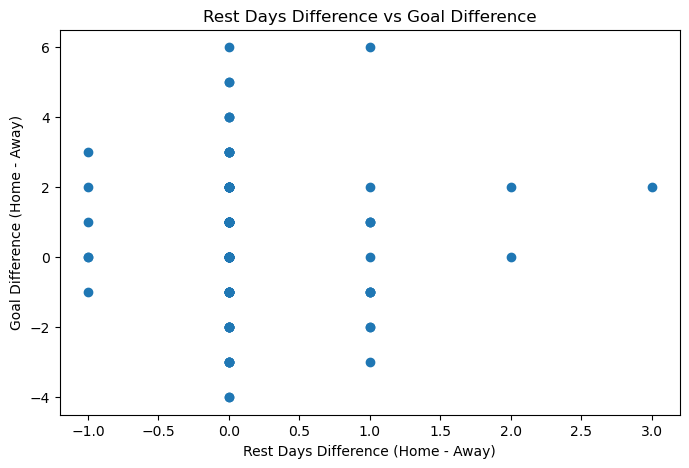

In [53]:
plt.figure(figsize=(8, 5))

plt.scatter(
    lr21_df["rest_days_difference"],
    lr21_df["goal_difference"]
)

plt.xlabel("Rest Days Difference (Home - Away)")
plt.ylabel("Goal Difference (Home - Away)")
plt.title("Rest Days Difference vs Goal Difference")

plt.show()

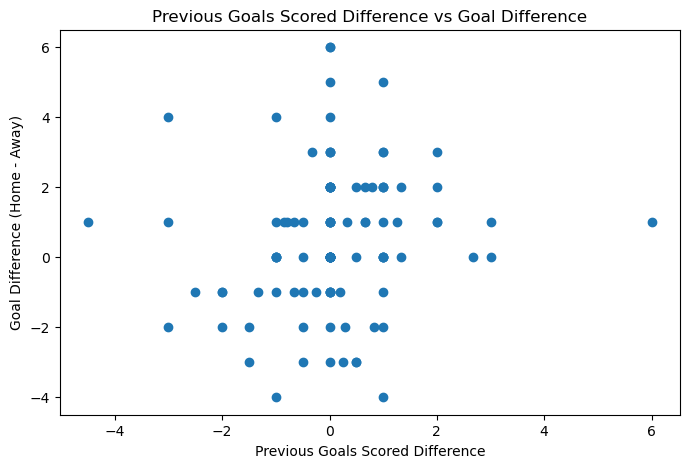

In [54]:
plt.figure(figsize=(8, 5))

plt.scatter(
    lr21_df["previous_goals_scored_difference"],
    lr21_df["goal_difference"]
)

plt.xlabel("Previous Goals Scored Difference")
plt.ylabel("Goal Difference (Home - Away)")
plt.title("Previous Goals Scored Difference vs Goal Difference")

plt.show()

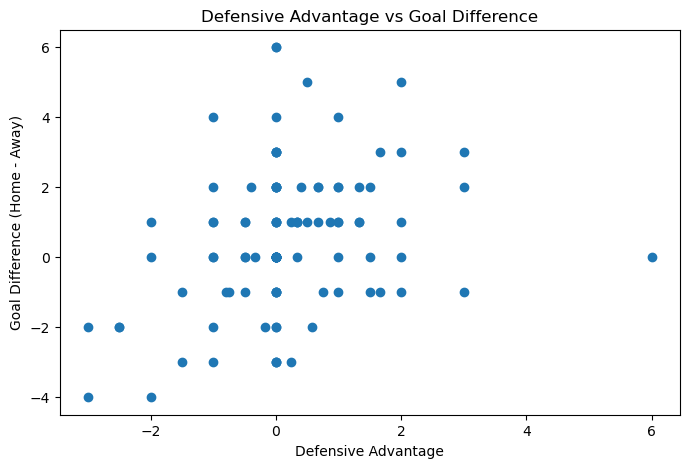

In [55]:
plt.figure(figsize=(8, 5))

plt.scatter(
    lr21_df["defensive_advantage"],
    lr21_df["goal_difference"]
)

plt.xlabel("Defensive Advantage")
plt.ylabel("Goal Difference (Home - Away)")
plt.title("Defensive Advantage vs Goal Difference")

plt.show()

In [56]:
import numpy as np

Q1 = np.percentile(lr21_df["goal_difference"], 25)
Q3 = np.percentile(lr21_df["goal_difference"], 75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: -1.0
Q3: 2.0
IQR: 3.0
Lower bound: -5.5
Upper bound: 6.5


In [57]:
lr21_df[
    (lr21_df["goal_difference"] < lower_bound) |
    (lr21_df["goal_difference"] > upper_bound)
]

,match_id,fifa_rank_advantage,elo_difference,squad_value_difference,squad_experience_difference,rest_days_difference,previous_goals_scored_difference,defensive_advantage,host_advantage,goal_difference


In [58]:
X = lr21_df[
    [
        "fifa_rank_advantage",
        "elo_difference",
        "squad_value_difference",
        "squad_experience_difference",
        "rest_days_difference",
        "previous_goals_scored_difference",
        "defensive_advantage",
        "host_advantage"
    ]
]

y = lr21_df["goal_difference"]

In [59]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (104, 8)
y shape: (104,)


In [60]:
lr21_df[
    [
        "fifa_rank_advantage",
        "elo_difference",
        "goal_difference"
    ]
].corr().round(2)

,fifa_rank_advantage,elo_difference,goal_difference
fifa_rank_advantage,1.00,0.94,0.61
elo_difference,0.94,1.00,0.65
goal_difference,0.61,0.65,1.00


In [61]:
model_df["previous_xg_scored_difference"] = (
    model_df["home_prev_avg_xg_scored"]
    - model_df["away_prev_avg_xg_scored"]
)

In [62]:
model_df[
    [
        "previous_xg_scored_difference",
        "fifa_rank_advantage",
        "elo_difference",
        "goal_difference"
    ]
].corr().round(2)

,previous_xg_scored_difference,fifa_rank_advantage,elo_difference,goal_difference
previous_xg_scored_difference,1.00,0.47,0.55,0.36
fifa_rank_advantage,0.47,1.00,0.94,0.61
elo_difference,0.55,0.94,1.00,0.65
goal_difference,0.36,0.61,0.65,1.00


In [63]:
model_df[
    [
        "fifa_rank_advantage",
        "elo_difference",
        "squad_value_difference",
        "squad_experience_difference",
        "rest_days_difference",
        "previous_goals_scored_difference",
        "defensive_advantage",
        "host_advantage",
        "previous_xg_scored_difference",
        "goal_difference"
    ]
].corr()[["previous_xg_scored_difference"]].round(2)

,previous_xg_scored_difference
fifa_rank_advantage,0.47
elo_difference,0.55
squad_value_difference,0.53
squad_experience_difference,0.15
rest_days_difference,-0.12
previous_goals_scored_difference,0.86
defensive_advantage,0.24
host_advantage,0.14
previous_xg_scored_difference,1.00
goal_difference,0.36


In [64]:
model_df["previous_shots_on_target_difference"] = (
    model_df["home_prev_avg_shots_on_target"]
    - model_df["away_prev_avg_shots_on_target"]
)

In [65]:
model_df[
    [
        "previous_shots_on_target_difference",
        "fifa_rank_advantage",
        "elo_difference",
        "squad_value_difference",
        "previous_goals_scored_difference",
        "defensive_advantage",
        "goal_difference"
    ]
].corr()[["previous_shots_on_target_difference"]].round(2)

,previous_shots_on_target_difference
previous_shots_on_target_difference,1.00
fifa_rank_advantage,0.49
elo_difference,0.56
squad_value_difference,0.54
previous_goals_scored_difference,0.62
defensive_advantage,0.15
goal_difference,0.31


In [66]:
candidate_features = [
    "elo_difference",
    "squad_value_difference",
    "squad_experience_difference",
    "rest_days_difference",
    "previous_goals_scored_difference",
    "defensive_advantage",
    "host_advantage",
    "previous_shots_on_target_difference"
]

model_df[candidate_features].corr().round(2)

,elo_difference,squad_value_difference,squad_experience_difference,rest_days_difference,previous_goals_scored_difference,defensive_advantage,host_advantage,previous_shots_on_target_difference
elo_difference,1.00,0.79,0.26,-0.11,0.36,0.33,0.02,0.56
squad_value_difference,0.79,1.00,0.01,-0.07,0.30,0.33,-0.03,0.54
squad_experience_difference,0.26,0.01,1.00,-0.10,0.18,0.07,0.20,0.10
rest_days_difference,-0.11,-0.07,-0.10,1.00,-0.02,0.02,0.10,-0.18
previous_goals_scored_difference,0.36,0.30,0.18,-0.02,1.00,0.01,0.18,0.62
defensive_advantage,0.33,0.33,0.07,0.02,0.01,1.00,0.08,0.15
host_advantage,0.02,-0.03,0.20,0.10,0.18,0.08,1.00,-0.11
previous_shots_on_target_difference,0.56,0.54,0.10,-0.18,0.62,0.15,-0.11,1.00


In [67]:
lr21_refined_df = model_df[
    [
        "match_id",
        "elo_difference",
        "squad_value_difference",
        "squad_experience_difference",
        "rest_days_difference",
        "previous_goals_scored_difference",
        "defensive_advantage",
        "host_advantage",
        "previous_shots_on_target_difference",
        "goal_difference"
    ]
].copy()

In [68]:
lr21_refined_df.shape

(104, 10)

In [69]:
X_original = lr21_df.drop(
    columns=["match_id", "goal_difference"]
)

X_refined = lr21_refined_df.drop(
    columns=["match_id", "goal_difference"]
)

y = lr21_df["goal_difference"]

In [70]:
print("Original X:", X_original.shape)
print("Refined X:", X_refined.shape)
print("y:", y.shape)

Original X: (104, 8)
Refined X: (104, 8)
y: (104,)


In [71]:
from sklearn.model_selection import train_test_split

(
    X_original_train,
    X_original_test,
    X_refined_train,
    X_refined_test,
    y_train,
    y_test
) = train_test_split(
    X_original,
    X_refined,
    y,
    test_size=0.20,
    random_state=42
)

In [72]:
print("Training matches:", len(y_train))
print("Testing matches:", len(y_test))

print("Original training shape:", X_original_train.shape)
print("Refined training shape:", X_refined_train.shape)

Training matches: 83
Testing matches: 21
Original training shape: (83, 8)
Refined training shape: (83, 8)


In [73]:
from sklearn.linear_model import LinearRegression

original_model = LinearRegression()
refined_model = LinearRegression()

original_model.fit(X_original_train, y_train)
refined_model.fit(X_refined_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [74]:
original_predictions = original_model.predict(X_original_test)
refined_predictions = refined_model.predict(X_refined_test)

In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

original_mae = mean_absolute_error(y_test, original_predictions)
original_rmse = np.sqrt(mean_squared_error(y_test, original_predictions))
original_r2 = r2_score(y_test, original_predictions)

refined_mae = mean_absolute_error(y_test, refined_predictions)
refined_rmse = np.sqrt(mean_squared_error(y_test, refined_predictions))
refined_r2 = r2_score(y_test, refined_predictions)

print("Original Model")
print("MAE:", round(original_mae, 3))
print("RMSE:", round(original_rmse, 3))
print("R²:", round(original_r2, 3))

print("\nRefined Model")
print("MAE:", round(refined_mae, 3))
print("RMSE:", round(refined_rmse, 3))
print("R²:", round(refined_r2, 3))

Original Model
MAE: 1.595
RMSE: 2.021
R²: -0.112

Refined Model
MAE: 1.529
RMSE: 1.968
R²: -0.054


In [76]:
original_train_predictions = original_model.predict(X_original_train)
refined_train_predictions = refined_model.predict(X_refined_train)

original_train_r2 = r2_score(y_train, original_train_predictions)
refined_train_r2 = r2_score(y_train, refined_train_predictions)

print("Original Training R²:", round(original_train_r2, 3))
print("Refined Training R²:", round(refined_train_r2, 3))

Original Training R²: 0.557
Refined Training R²: 0.555


In [77]:
n = len(y_train)
p = X_original_train.shape[1]

original_adjusted_r2 = 1 - (
    (1 - original_train_r2) * (n - 1) / (n - p - 1)
)

refined_adjusted_r2 = 1 - (
    (1 - refined_train_r2) * (n - 1) / (n - p - 1)
)

print("Original Adjusted R²:", round(original_adjusted_r2, 3))
print("Refined Adjusted R²:", round(refined_adjusted_r2, 3))

Original Adjusted R²: 0.509
Refined Adjusted R²: 0.507


In [78]:
refined_residuals = y_test - refined_predictions

In [79]:
refined_residuals

30    1.862407
65   -0.400277
64    1.075082
53   -0.437059
45   -0.263798
93   -3.340769
91   -0.431248
47   -1.040522
10    1.381939
0     0.227227
18    0.728151
31   -2.452379
88    1.249087
95    1.330336
77    0.702953
4     1.498701
80   -0.547633
33   -4.200935
12   -3.525649
26    4.163090
98    1.255188
Name: goal_difference, dtype: float64

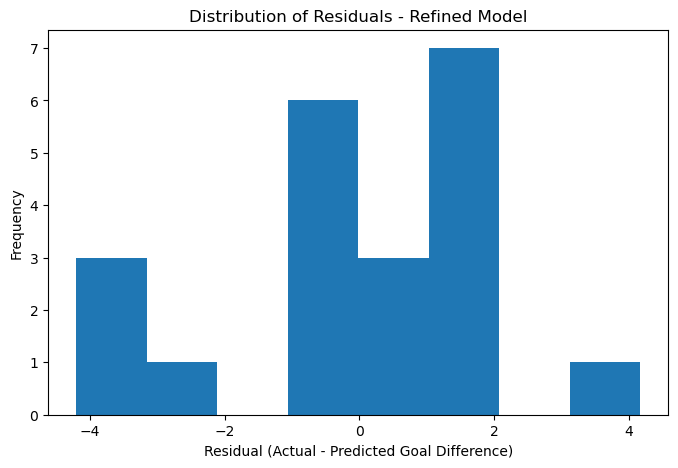

In [80]:
plt.figure(figsize=(8, 5))

plt.hist(
    refined_residuals,
    bins=8
)

plt.xlabel("Residual (Actual - Predicted Goal Difference)")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals - Refined Model")

plt.show()

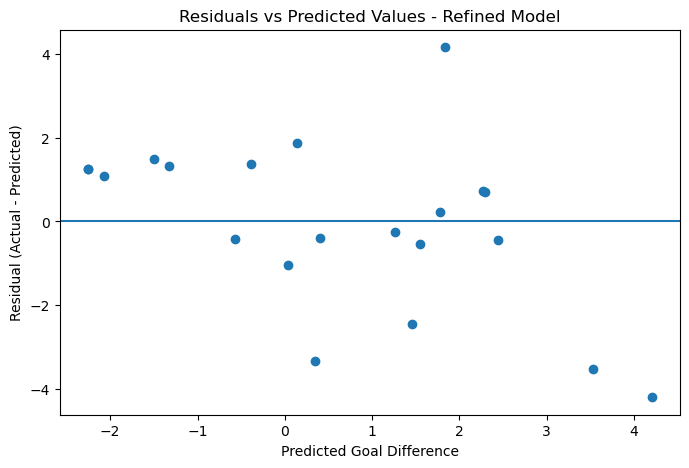

In [81]:
plt.figure(figsize=(8, 5))

plt.scatter(
    refined_predictions,
    refined_residuals
)

plt.axhline(y=0)

plt.xlabel("Predicted Goal Difference")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted Values - Refined Model")

plt.show()

In [82]:
refined_coefficients = pd.DataFrame({
    "Variable": X_refined.columns,
    "Coefficient": refined_model.coef_
})

refined_coefficients

,Variable,Coefficient
0,elo_difference,5.059964e-03
1,squad_value_difference,4.794243e-10
2,squad_experience_difference,-3.635610e-04
3,rest_days_difference,-2.770293e-01
4,previous_goals_scored_difference,-2.238456e-01
5,defensive_advantage,3.444264e-01
6,host_advantage,8.016818e-01
7,previous_shots_on_target_difference,-2.627670e-02


In [83]:
print("Intercept:", refined_model.intercept_)

Intercept: 0.08921818266293685


In [84]:
prediction_results = pd.DataFrame({
    "Actual_Goal_Difference": y_test,
    "Predicted_Goal_Difference": refined_predictions,
    "Residual": refined_residuals
}).round(2)

prediction_results

,Actual_Goal_Difference,Predicted_Goal_Difference,Residual
30,2,0.14,1.86
65,0,0.40,-0.40
64,-1,-2.08,1.08
53,2,2.44,-0.44
45,1,1.26,-0.26
93,-3,0.34,-3.34
91,-1,-0.57,-0.43
47,-1,0.04,-1.04
10,1,-0.38,1.38
0,2,1.77,0.23


In [85]:
prediction_results.to_csv(
    "../outputs/lr21_refined_predictions.csv",
    index=False
)

In [86]:
lr21_refined_df.to_csv(
    "../data/linear_regression_2_1_refined_dataset.csv",
    index=False
)

In [87]:
model_comparison = pd.DataFrame({
    "Model": ["Original", "Refined"],
    "Training_R2": [
        original_train_r2,
        refined_train_r2
    ],
    "Adjusted_Training_R2": [
        original_adjusted_r2,
        refined_adjusted_r2
    ],
    "Test_MAE": [
        original_mae,
        refined_mae
    ],
    "Test_RMSE": [
        original_rmse,
        refined_rmse
    ],
    "Test_R2": [
        original_r2,
        refined_r2
    ]
})

model_comparison.round(3)

,Model,Training_R2,Adjusted_Training_R2,Test_MAE,Test_RMSE,Test_R2
0,Original,0.557,0.509,1.595,2.021,-0.112
1,Refined,0.555,0.507,1.529,1.968,-0.054


In [88]:
model_comparison.round(3).to_csv(
    "../outputs/lr21_model_comparison.csv",
    index=False
)

In [89]:
model_df["previous_possession_difference"] = (
    model_df["home_prev_avg_possession"]
    - model_df["away_prev_avg_possession"]
)

In [90]:
model_df[
    [
        "previous_possession_difference",
        "elo_difference",
        "squad_value_difference",
        "previous_goals_scored_difference",
        "defensive_advantage",
        "previous_shots_on_target_difference",
        "goal_difference"
    ]
].corr()[["previous_possession_difference"]].round(2)

,previous_possession_difference
previous_possession_difference,1.00
elo_difference,0.57
squad_value_difference,0.51
previous_goals_scored_difference,0.34
defensive_advantage,0.26
previous_shots_on_target_difference,0.64
goal_difference,0.44


In [91]:
lr21_candidate3_df = model_df[
    [
        "match_id",
        "elo_difference",
        "squad_value_difference",
        "squad_experience_difference",
        "previous_possession_difference",
        "previous_goals_scored_difference",
        "defensive_advantage",
        "host_advantage",
        "previous_shots_on_target_difference",
        "goal_difference"
    ]
].copy()

In [92]:
lr21_candidate3_df.shape

(104, 10)

In [93]:
X_candidate3 = lr21_candidate3_df.drop(
    columns=["match_id", "goal_difference"]
)

X_candidate3_train = X_candidate3.loc[y_train.index]
X_candidate3_test = X_candidate3.loc[y_test.index]

candidate3_model = LinearRegression()
candidate3_model.fit(X_candidate3_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [94]:
candidate3_predictions = candidate3_model.predict(X_candidate3_test)

candidate3_mae = mean_absolute_error(y_test, candidate3_predictions)
candidate3_rmse = np.sqrt(mean_squared_error(y_test, candidate3_predictions))
candidate3_r2 = r2_score(y_test, candidate3_predictions)

candidate3_train_predictions = candidate3_model.predict(X_candidate3_train)
candidate3_train_r2 = r2_score(y_train, candidate3_train_predictions)

n = len(y_train)
p = X_candidate3_train.shape[1]

candidate3_adjusted_r2 = 1 - (
    (1 - candidate3_train_r2) * (n - 1) / (n - p - 1)
)

print("Candidate 3 Model")
print("Training R²:", round(candidate3_train_r2, 3))
print("Adjusted Training R²:", round(candidate3_adjusted_r2, 3))
print("Test MAE:", round(candidate3_mae, 3))
print("Test RMSE:", round(candidate3_rmse, 3))
print("Test R²:", round(candidate3_r2, 3))

Candidate 3 Model
Training R²: 0.553
Adjusted Training R²: 0.504
Test MAE: 1.43
Test RMSE: 1.839
Test R²: 0.079


In [95]:
model_df["previous_shots_difference"] = (
    model_df["home_prev_avg_shots"]
    - model_df["away_prev_avg_shots"]
)

In [96]:
model_df[
    [
        "previous_shots_difference",
        "elo_difference",
        "squad_value_difference",
        "previous_possession_difference",
        "previous_goals_scored_difference",
        "defensive_advantage",
        "host_advantage",
        "previous_shots_on_target_difference",
        "goal_difference"
    ]
].corr()[["previous_shots_difference"]].round(2)

,previous_shots_difference
previous_shots_difference,1.00
elo_difference,0.42
squad_value_difference,0.40
previous_possession_difference,0.69
previous_goals_scored_difference,0.26
defensive_advantage,0.16
host_advantage,-0.10
previous_shots_on_target_difference,0.78
goal_difference,0.28


In [97]:
model_df["squad_age_difference"] = (
    model_df["home_squad_avg_age"]
    - model_df["away_squad_avg_age"]
)

In [98]:
model_df[
    [
        "squad_age_difference",
        "elo_difference",
        "squad_value_difference",
        "squad_experience_difference",
        "previous_possession_difference",
        "previous_goals_scored_difference",
        "defensive_advantage",
        "host_advantage",
        "previous_shots_on_target_difference",
        "goal_difference"
    ]
].corr()[["squad_age_difference"]].round(2)

,squad_age_difference
squad_age_difference,1.00
elo_difference,-0.06
squad_value_difference,-0.25
squad_experience_difference,0.59
previous_possession_difference,-0.13
previous_goals_scored_difference,0.12
defensive_advantage,-0.10
host_advantage,-0.07
previous_shots_on_target_difference,-0.06
goal_difference,-0.06


In [99]:
model_df[
    [
        "is_knockout",
        "elo_difference",
        "squad_value_difference",
        "squad_experience_difference",
        "previous_possession_difference",
        "previous_goals_scored_difference",
        "defensive_advantage",
        "host_advantage",
        "previous_shots_on_target_difference",
        "goal_difference"
    ]
].corr()[["is_knockout"]].round(2)

,is_knockout
is_knockout,1.00
elo_difference,0.05
squad_value_difference,0.10
squad_experience_difference,0.05
previous_possession_difference,-0.08
previous_goals_scored_difference,0.08
defensive_advantage,0.15
host_advantage,0.11
previous_shots_on_target_difference,-0.04
goal_difference,-0.09


In [100]:
lr21_candidate4_df = model_df[
    [
        "match_id",
        "elo_difference",
        "squad_value_difference",
        "is_knockout",
        "previous_possession_difference",
        "previous_goals_scored_difference",
        "defensive_advantage",
        "host_advantage",
        "previous_shots_on_target_difference",
        "goal_difference"
    ]
].copy()

In [101]:
lr21_candidate4_df.shape

(104, 10)

In [102]:
X_candidate4 = lr21_candidate4_df.drop(
    columns=["match_id", "goal_difference"]
)

X_candidate4_train = X_candidate4.loc[y_train.index]
X_candidate4_test = X_candidate4.loc[y_test.index]

candidate4_model = LinearRegression()
candidate4_model.fit(X_candidate4_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [103]:
candidate4_predictions = candidate4_model.predict(X_candidate4_test)

candidate4_mae = mean_absolute_error(y_test, candidate4_predictions)
candidate4_rmse = np.sqrt(mean_squared_error(y_test, candidate4_predictions))
candidate4_r2 = r2_score(y_test, candidate4_predictions)

candidate4_train_predictions = candidate4_model.predict(X_candidate4_train)
candidate4_train_r2 = r2_score(y_train, candidate4_train_predictions)

n = len(y_train)
p = X_candidate4_train.shape[1]

candidate4_adjusted_r2 = 1 - (
    (1 - candidate4_train_r2) * (n - 1) / (n - p - 1)
)

print("Candidate 4 Model")
print("Training R²:", round(candidate4_train_r2, 3))
print("Adjusted Training R²:", round(candidate4_adjusted_r2, 3))
print("Test MAE:", round(candidate4_mae, 3))
print("Test RMSE:", round(candidate4_rmse, 3))
print("Test R²:", round(candidate4_r2, 3))

Candidate 4 Model
Training R²: 0.599
Adjusted Training R²: 0.556
Test MAE: 1.641
Test RMSE: 2.064
Test R²: -0.159


In [104]:
model_comparison = pd.DataFrame({
    "Model": [
        "Original",
        "Refined",
        "Candidate 3",
        "Candidate 4"
    ],
    "Training_R2": [
        original_train_r2,
        refined_train_r2,
        candidate3_train_r2,
        candidate4_train_r2
    ],
    "Adjusted_Training_R2": [
        original_adjusted_r2,
        refined_adjusted_r2,
        candidate3_adjusted_r2,
        candidate4_adjusted_r2
    ],
    "Test_MAE": [
        original_mae,
        refined_mae,
        candidate3_mae,
        candidate4_mae
    ],
    "Test_RMSE": [
        original_rmse,
        refined_rmse,
        candidate3_rmse,
        candidate4_rmse
    ],
    "Test_R2": [
        original_r2,
        refined_r2,
        candidate3_r2,
        candidate4_r2
    ]
})

model_comparison.round(3)

,Model,Training_R2,Adjusted_Training_R2,Test_MAE,Test_RMSE,Test_R2
0,Original,0.557,0.509,1.595,2.021,-0.112
1,Refined,0.555,0.507,1.529,1.968,-0.054
2,Candidate 3,0.553,0.504,1.430,1.839,0.079
3,Candidate 4,0.599,0.556,1.641,2.064,-0.159


In [105]:
model_comparison.round(3).to_csv(
    "../outputs/lr21_model_comparison.csv",
    index=False
)

In [106]:
lr21_candidate3_df.to_csv(
    "../data/linear_regression_2_1_candidate3_dataset.csv",
    index=False
)

In [107]:
candidate3_residuals = y_test - candidate3_predictions

candidate3_results = pd.DataFrame({
    "Actual_Goal_Difference": y_test,
    "Predicted_Goal_Difference": candidate3_predictions,
    "Residual": candidate3_residuals
}).round(2)

candidate3_results

,Actual_Goal_Difference,Predicted_Goal_Difference,Residual
30,2,0.77,1.23
65,0,0.30,-0.30
64,-1,-2.08,1.08
53,2,2.36,-0.36
45,1,1.59,-0.59
93,-3,0.27,-3.27
91,-1,-0.73,-0.27
47,-1,0.06,-1.06
10,1,-0.45,1.45
0,2,1.60,0.40


In [108]:
candidate3_results.to_csv(
    "../outputs/lr21_candidate3_predictions.csv",
    index=False
)

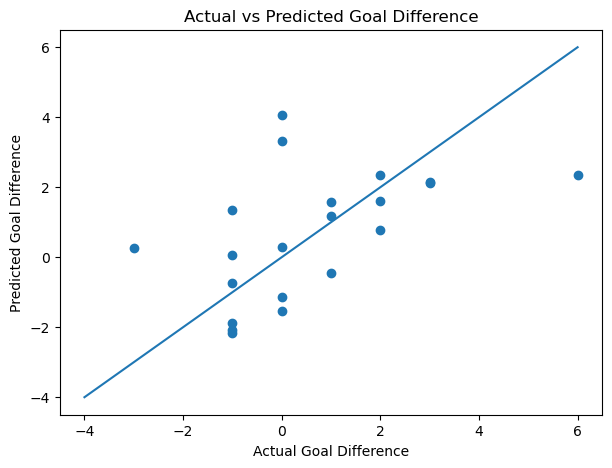

In [109]:
plt.figure(figsize=(7, 5))

plt.scatter(
    candidate3_results["Actual_Goal_Difference"],
    candidate3_results["Predicted_Goal_Difference"]
)

plt.plot(
    [-4, 6],
    [-4, 6]
)

plt.xlabel("Actual Goal Difference")
plt.ylabel("Predicted Goal Difference")
plt.title("Actual vs Predicted Goal Difference")

plt.show()

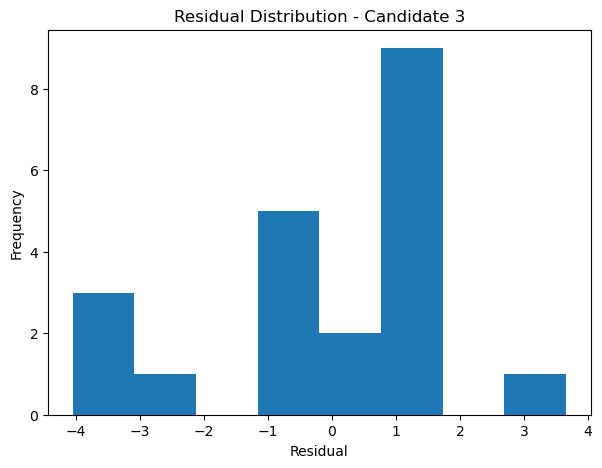

In [110]:
plt.figure(figsize=(7, 5))

plt.hist(
    candidate3_residuals,
    bins=8
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution - Candidate 3")

plt.show()

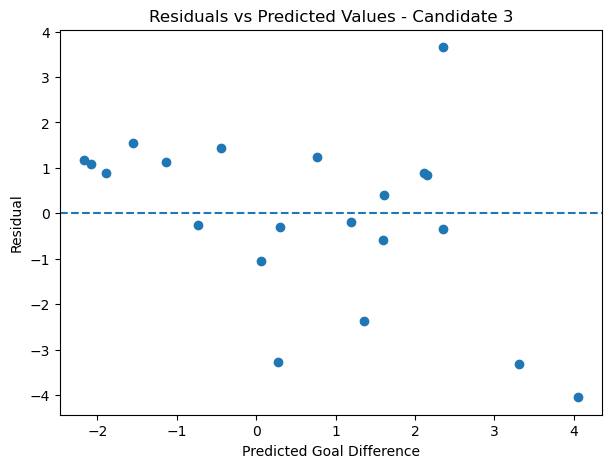

In [111]:
plt.figure(figsize=(7, 5))

plt.scatter(
    candidate3_predictions,
    candidate3_residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Goal Difference")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values - Candidate 3")

plt.show()

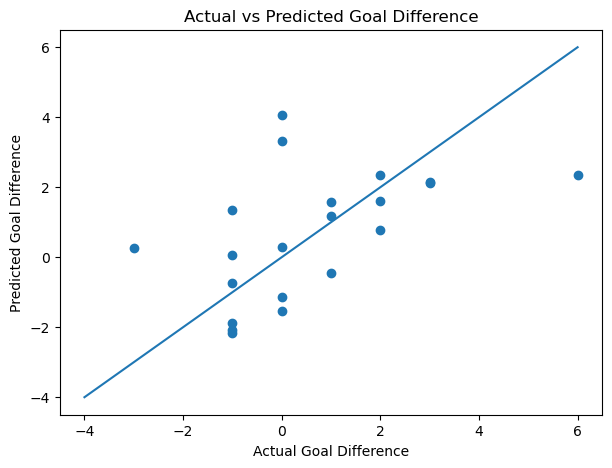

In [112]:
plt.figure(figsize=(7, 5))

plt.scatter(
    candidate3_results["Actual_Goal_Difference"],
    candidate3_results["Predicted_Goal_Difference"]
)

plt.plot(
    [-4, 6],
    [-4, 6]
)

plt.xlabel("Actual Goal Difference")
plt.ylabel("Predicted Goal Difference")
plt.title("Actual vs Predicted Goal Difference")

plt.savefig(
    "../outputs/lr21_actual_vs_predicted.png",
    bbox_inches="tight"
)

plt.show()

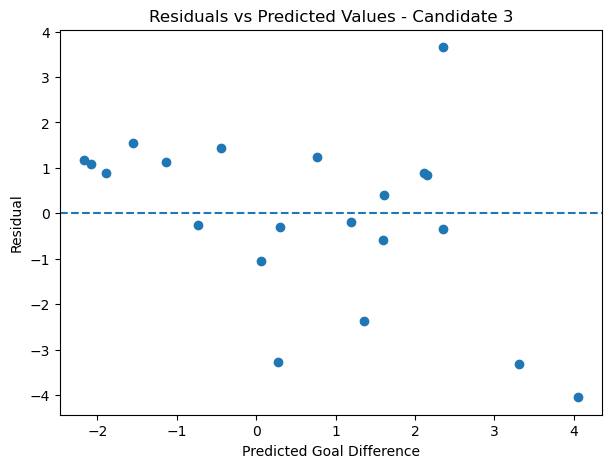

In [113]:
plt.figure(figsize=(7, 5))

plt.scatter(
    candidate3_predictions,
    candidate3_residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Goal Difference")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values - Candidate 3")

plt.savefig(
    "../outputs/lr21_residuals_vs_predicted.png",
    bbox_inches="tight"
)

plt.show()

### Residual Diagnostic Interpretation

The residuals were distributed on both sides of zero, but they were not completely random across the range of predicted goal differences.

Several negative predicted goal differences had positive residuals, while some of the largest positive predicted goal differences had strongly negative residuals. This suggests that the model may sometimes produce predictions that are too extreme, particularly for matches predicted to have large winning margins.

There was no obvious strong funnel-shaped pattern, although several relatively large residuals were present. Since the test set contained only 21 matches, the residual pattern should be interpreted cautiously.

Overall, the diagnostic plot suggests that the multiple linear regression model captures some of the relationship in the data but does not fully explain the variation in unseen match outcomes. This is consistent with the relatively low test R² of 0.079.

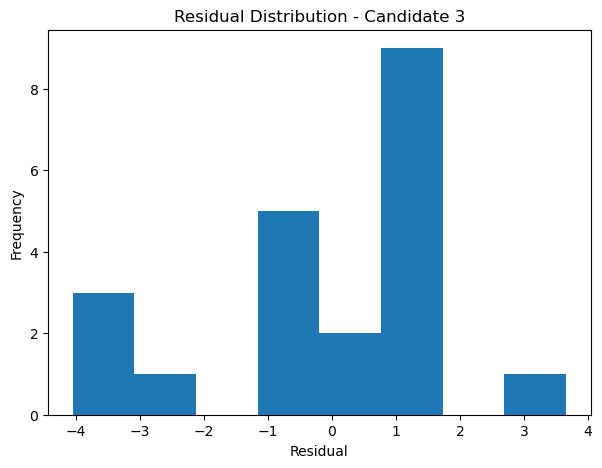

In [114]:
plt.figure(figsize=(7, 5))

plt.hist(
    candidate3_residuals,
    bins=8
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution - Candidate 3")

plt.savefig(
    "../outputs/lr21_residual_distribution.png",
    bbox_inches="tight"
)

plt.show()

### LR 2.1 Summary

A multiple linear regression model was developed to predict the goal difference between two opposing teams using 104 FIFA World Cup 2026 matches and eight pre-match explanatory variables.

Exploratory data analysis, correlation analysis, feature comparison and IQR-based outlier assessment were used to refine the predictor set. The current baseline model achieved a test MAE of 1.430 goals, RMSE of 1.839 goals and R² of 0.079.

The model performed better than the earlier feature combinations tested, but the relatively low test R² and residual patterns indicate that substantial variation in match goal difference remains unexplained. Therefore, the model should be treated as a baseline rather than a highly accurate predictor.

The final group analysis should compare this baseline with alternative modelling approaches and confirm that the LR 2.1 and LR 2.2 models share no more than four explanatory variables.

In [115]:
candidate3_coefficients = pd.DataFrame({
    "Variable": X_candidate3.columns,
    "Coefficient": candidate3_model.coef_
})

candidate3_coefficients

,Variable,Coefficient
0,elo_difference,4.991661e-03
1,squad_value_difference,4.196987e-10
2,squad_experience_difference,-4.047391e-04
3,previous_possession_difference,1.470558e-02
4,previous_goals_scored_difference,-2.098660e-01
5,defensive_advantage,3.089827e-01
6,host_advantage,7.567491e-01
7,previous_shots_on_target_difference,-4.878733e-02


In [116]:
print("Intercept:", candidate3_model.intercept_)

Intercept: 0.028421157763939164


In [117]:
candidate3_coefficient_summary = pd.concat(
    [
        pd.DataFrame({
            "Variable": ["Intercept"],
            "Coefficient": [candidate3_model.intercept_]
        }),
        candidate3_coefficients
    ],
    ignore_index=True
)

candidate3_coefficient_summary

,Variable,Coefficient
0,Intercept,2.842116e-02
1,elo_difference,4.991661e-03
2,squad_value_difference,4.196987e-10
3,squad_experience_difference,-4.047391e-04
4,previous_possession_difference,1.470558e-02
5,previous_goals_scored_difference,-2.098660e-01
6,defensive_advantage,3.089827e-01
7,host_advantage,7.567491e-01
8,previous_shots_on_target_difference,-4.878733e-02


In [118]:
candidate3_coefficient_summary.to_csv(
    "../outputs/lr21_candidate3_coefficients.csv",
    index=False
)

In [119]:
candidate3_descriptive_stats = lr21_candidate3_df.drop(
    columns=["match_id"]
).describe()

candidate3_descriptive_stats.round(2)

,elo_difference,squad_value_difference,squad_experience_difference,previous_possession_difference,previous_goals_scored_difference,defensive_advantage,host_advantage,previous_shots_on_target_difference,goal_difference
count,104.00,1.040000e+02,104.00,104.00,104.00,104.00,104.00,104.00,104.00
mean,57.02,1.809516e+08,52.43,4.44,0.07,0.18,0.07,0.60,0.48
std,236.67,6.817432e+08,307.60,12.32,1.33,1.27,0.35,2.73,2.02
min,-540.00,-1.813827e+09,-973.00,-26.00,-4.50,-3.00,-1.00,-6.50,-4.00
25%,-112.50,-1.674659e+08,-104.25,-1.00,-0.50,-0.21,0.00,-0.67,-1.00
50%,60.00,1.530351e+08,74.50,0.00,0.00,0.00,0.00,0.00,0.00
75%,226.25,4.899664e+08,266.50,11.00,0.81,0.69,0.00,2.00,2.00
max,510.00,2.038847e+09,703.00,47.00,6.00,6.00,1.00,9.00,6.00


In [120]:
candidate3_descriptive_stats.round(2).to_csv(
    "../outputs/lr21_candidate3_descriptive_statistics.csv"
)

In [121]:
candidate3_correlation = lr21_candidate3_df.drop(
    columns=["match_id"]
).corr()

candidate3_correlation.round(2)

,elo_difference,squad_value_difference,squad_experience_difference,previous_possession_difference,previous_goals_scored_difference,defensive_advantage,host_advantage,previous_shots_on_target_difference,goal_difference
elo_difference,1.00,0.79,0.26,0.57,0.36,0.33,0.02,0.56,0.65
squad_value_difference,0.79,1.00,0.01,0.51,0.30,0.33,-0.03,0.54,0.57
squad_experience_difference,0.26,0.01,1.00,0.15,0.18,0.07,0.20,0.10,0.09
previous_possession_difference,0.57,0.51,0.15,1.00,0.34,0.26,0.08,0.64,0.44
previous_goals_scored_difference,0.36,0.30,0.18,0.34,1.00,0.01,0.18,0.62,0.14
defensive_advantage,0.33,0.33,0.07,0.26,0.01,1.00,0.08,0.15,0.31
host_advantage,0.02,-0.03,0.20,0.08,0.18,0.08,1.00,-0.11,0.16
previous_shots_on_target_difference,0.56,0.54,0.10,0.64,0.62,0.15,-0.11,1.00,0.31
goal_difference,0.65,0.57,0.09,0.44,0.14,0.31,0.16,0.31,1.00


In [122]:
candidate3_correlation.round(2).to_csv(
    "../outputs/lr21_candidate3_correlation.csv"
)

In [123]:
print("Shape:", lr21_candidate3_df.shape)

print("\nMissing values:")
print(lr21_candidate3_df.isnull().sum())

print(
    "\nDuplicate match IDs:",
    lr21_candidate3_df["match_id"].duplicated().sum()
)

Shape: (104, 10)

Missing values:
match_id                               0
elo_difference                         0
squad_value_difference                 0
squad_experience_difference            0
previous_possession_difference         0
previous_goals_scored_difference       0
defensive_advantage                    0
host_advantage                         0
previous_shots_on_target_difference    0
goal_difference                        0
dtype: int64

Duplicate match IDs: 0


In [124]:
continuous_predictors = [
    "elo_difference",
    "squad_value_difference",
    "squad_experience_difference",
    "previous_possession_difference",
    "previous_goals_scored_difference",
    "defensive_advantage",
    "previous_shots_on_target_difference"
]

outlier_summary = []

for column in continuous_predictors:
    Q1 = lr21_candidate3_df[column].quantile(0.25)
    Q3 = lr21_candidate3_df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (lr21_candidate3_df[column] < lower_bound) |
        (lr21_candidate3_df[column] > upper_bound)
    ).sum()

    outlier_summary.append([
        column,
        lower_bound,
        upper_bound,
        outlier_count
    ])

outlier_summary_df = pd.DataFrame(
    outlier_summary,
    columns=[
        "Variable",
        "Lower_Bound",
        "Upper_Bound",
        "Outlier_Count"
    ]
)

outlier_summary_df.round(2)

,Variable,Lower_Bound,Upper_Bound,Outlier_Count
0,elo_difference,-6.206200e+02,7.343800e+02,0
1,squad_value_difference,-1.153614e+09,1.476115e+09,6
2,squad_experience_difference,-6.603800e+02,8.226200e+02,2
3,previous_possession_difference,-1.900000e+01,2.900000e+01,9
4,previous_goals_scored_difference,-2.460000e+00,2.770000e+00,8
5,defensive_advantage,-1.550000e+00,2.030000e+00,11
6,previous_shots_on_target_difference,-4.670000e+00,6.000000e+00,7


In [125]:
outlier_summary_df.round(2).to_csv(
    "../outputs/lr21_candidate3_outlier_summary.csv",
    index=False
)

In [126]:
candidate3_mse = mean_squared_error(
    y_test,
    candidate3_predictions
)

print("Candidate 3 Test MSE:", round(candidate3_mse, 3))

Candidate 3 Test MSE: 3.382


In [127]:
original_mse = mean_squared_error(
    y_test,
    original_predictions
)

refined_mse = mean_squared_error(
    y_test,
    refined_predictions
)

candidate4_mse = mean_squared_error(
    y_test,
    candidate4_predictions
)

print("Original MSE:", round(original_mse, 3))
print("Refined MSE:", round(refined_mse, 3))
print("Candidate 3 MSE:", round(candidate3_mse, 3))
print("Candidate 4 MSE:", round(candidate4_mse, 3))

Original MSE: 4.084
Refined MSE: 3.873
Candidate 3 MSE: 3.382
Candidate 4 MSE: 4.259


In [128]:
model_comparison["Test_MSE"] = [
    original_mse,
    refined_mse,
    candidate3_mse,
    candidate4_mse
]

model_comparison.round(3)

,Model,Training_R2,Adjusted_Training_R2,Test_MAE,Test_RMSE,Test_R2,Test_MSE
0,Original,0.557,0.509,1.595,2.021,-0.112,4.084
1,Refined,0.555,0.507,1.529,1.968,-0.054,3.873
2,Candidate 3,0.553,0.504,1.430,1.839,0.079,3.382
3,Candidate 4,0.599,0.556,1.641,2.064,-0.159,4.259


In [129]:
model_comparison.round(3).to_csv(
    "../outputs/lr21_model_comparison.csv",
    index=False
)

In [130]:
candidate3_metrics = pd.DataFrame({
    "Training_R2": [candidate3_train_r2],
    "Adjusted_Training_R2": [candidate3_adjusted_r2],
    "Test_MAE": [candidate3_mae],
    "Test_MSE": [candidate3_mse],
    "Test_RMSE": [candidate3_rmse],
    "Test_R2": [candidate3_r2],
    "Training_Matches": [len(y_train)],
    "Test_Matches": [len(y_test)]
})

candidate3_metrics.round(3)

,Training_R2,Adjusted_Training_R2,Test_MAE,Test_MSE,Test_RMSE,Test_R2,Training_Matches,Test_Matches
0,0.553,0.504,1.43,3.382,1.839,0.079,83,21


In [131]:
candidate3_metrics.round(3).to_csv(
    "../outputs/lr21_candidate3_metrics.csv",
    index=False
)

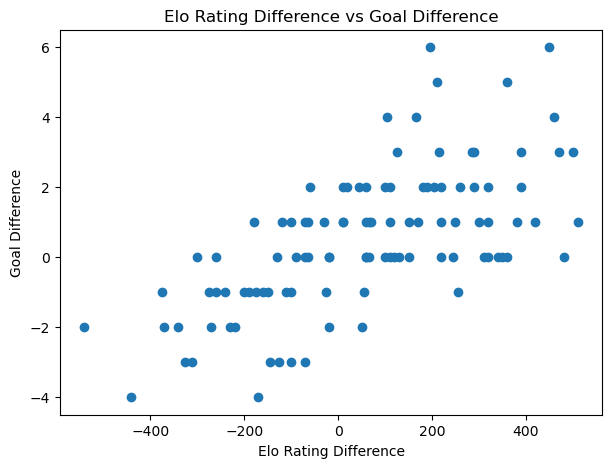

In [132]:
plt.figure(figsize=(7, 5))

plt.scatter(
    lr21_candidate3_df["elo_difference"],
    lr21_candidate3_df["goal_difference"]
)

plt.xlabel("Elo Rating Difference")
plt.ylabel("Goal Difference")
plt.title("Elo Rating Difference vs Goal Difference")

plt.savefig(
    "../outputs/lr21_elo_vs_goal_difference.png",
    bbox_inches="tight"
)

plt.show()

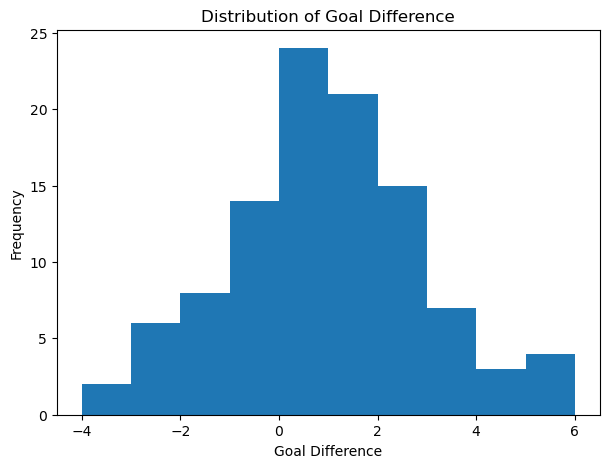

In [133]:
plt.figure(figsize=(7, 5))

plt.hist(
    lr21_candidate3_df["goal_difference"],
    bins=10
)

plt.xlabel("Goal Difference")
plt.ylabel("Frequency")
plt.title("Distribution of Goal Difference")

plt.savefig(
    "../outputs/lr21_goal_difference_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [134]:
targets_check = pd.read_csv(
    "../data/match_prediction_targets_y.csv"
)

targets_check["result_type"].value_counts(dropna=False)

result_type
Regular      96
AET           5
Penalties     3
Name: count, dtype: int64

In [135]:
targets_check[
    targets_check["result_type"].isin(["AET", "Penalties"])
][
    [
        "match_id",
        "home_score",
        "away_score",
        "result_type",
        "home_xg",
        "away_xg",
        "match_result"
    ]
]

,match_id,home_score,away_score,result_type,home_xg,away_xg,match_result
74,75,1,1,Penalties,0.72,0.42,D
75,76,1,1,Penalties,0.23,1.40,D
80,81,3,2,AET,1.74,3.58,H
85,86,1,1,Penalties,0.87,1.36,D
86,87,3,2,AET,2.16,0.46,H
98,99,1,2,AET,0.77,0.96,A
99,100,3,1,AET,2.00,0.53,H
103,104,1,0,AET,1.42,0.88,H


### Response Variable Check

The response variable for Linear Regression 2.1 was defined as:

Goal Difference = Home Score - Away Score

The target dataset contained 96 regular-time matches, 5 matches decided after extra time (AET), and 3 matches decided by penalties.

The penalty matches were recorded as drawn scores (1-1) with match_result = D, indicating that penalty shootout kicks were not included in the recorded home and away scores. Therefore, the supplied home_score and away_score values were retained for all 104 matches, and no matches were removed or modified.

### Multiple Linear Regression Modelling

The dataset was divided into training and testing subsets using an 80/20 split with random_state=42 to make the analysis reproducible.

Multiple Linear Regression was fitted using LinearRegression() from scikit-learn. The same training and testing observations were used when comparing alternative feature sets so that model performance could be compared consistently.

Model performance was assessed using:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R-squared (R²)
- Adjusted R-squared for the training data

Lower MAE, MSE and RMSE values indicate smaller prediction errors, while higher R² values indicate that a greater proportion of variation in goal difference is explained by the model.

### Feature Selection and EDA Decisions

Eight pre-match explanatory variables were required for Linear Regression 2.1.

The initial feature set included FIFA ranking advantage and rest-days difference. Exploratory analysis showed that FIFA ranking advantage was very strongly correlated with Elo difference (approximately r = 0.94), indicating substantial overlap between these predictors. FIFA ranking advantage was therefore replaced with previous shots-on-target difference.

Rest-days difference showed almost no linear relationship with goal difference (approximately r = -0.01). Previous possession difference showed a stronger relationship with goal difference (approximately r = 0.44) and was therefore tested as an alternative.

Several other possible predictors, including previous shots difference, squad age difference and knockout-stage status, were also examined. They were not retained because they either added substantial overlap with existing predictors or did not improve test-set performance.

The current working feature set contains:
1. Elo rating difference
2. Squad value difference
3. Squad experience difference
4. Previous possession difference
5. Previous average goals scored difference
6. Defensive advantage based on previous goals conceded
7. Host advantage
8. Previous shots-on-target difference

This feature set produced the strongest test performance among the exploratory feature sets examined and is retained as the current LR 2.1 baseline. Final coordination with LR 2.2 will still be required to ensure that no more than four explanatory variables are shared between the two regression tasks.

### Data Quality and Outlier Assessment

The final working LR 2.1 dataset contained 104 matches, eight explanatory variables and one response variable. No missing values or duplicate match IDs were identified.

Potential outliers in the continuous explanatory variables were examined using the 1.5 × IQR method. The analysis identified several observations outside the IQR bounds, including observations for squad value difference, squad experience difference, previous possession difference, previous goals scored difference, defensive advantage, and previous shots-on-target difference.

These observations were retained because large differences between national teams are plausible in an international football tournament and there was no evidence that the values represented data-entry errors. The response variable, goal difference, was also checked using the IQR method and no outliers were identified.

### LR 2.1 Baseline Model Results

The current LR 2.1 multiple linear regression model was trained on 83 matches and evaluated on 21 held-out matches.

The model achieved:

- Training R² = 0.553
- Adjusted Training R² = 0.504
- Test MAE = 1.430 goals
- Test MSE = 3.382
- Test RMSE = 1.839 goals
- Test R² = 0.079

The training R² indicates that the model explained approximately 55.3% of the variation in goal difference within the training data. However, the test R² was much lower at 0.079, indicating that only a small proportion of variation in the held-out match outcomes was explained.

The MAE of 1.430 indicates that predictions differed from the actual goal difference by approximately 1.43 goals on average. The RMSE of 1.839 is higher than the MAE because larger prediction errors receive greater weight.

The difference between training and test performance indicates that the model generalises less effectively to unseen matches than it fits the training data. Therefore, these results should be interpreted cautiously and the model should be compared with alternative modelling approaches during the group's final model-comparison stage.

### Interpretation of Regression Coefficients

The regression coefficients represent the expected change in predicted goal difference when one explanatory variable increases by one unit while the other variables are held constant.

The largest clearly interpretable positive coefficient was for host_advantage (approximately 0.757), suggesting that host status was associated with a higher predicted goal difference after accounting for the other variables. defensive_advantage also had a positive coefficient of approximately 0.309.

The coefficient for elo_difference was positive (approximately 0.005 per Elo point), indicating that teams with a higher Elo rating relative to their opponent tended to have a higher predicted goal difference.

Some variables, including previous_goals_scored_difference and previous_shots_on_target_difference, had negative coefficients despite having positive simple correlations with goal difference. These coefficients should not be interpreted in isolation because multiple regression estimates each relationship while holding the other predictors constant. Several football-performance variables are correlated with one another, which can affect the direction and magnitude of individual coefficients.

Coefficient sizes should also not be directly compared as measures of importance because the predictors are measured on very different scales. For example, squad value is measured in euros while host advantage is represented by small indicator values.